In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


# 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset (Real Data)

In [3]:
df = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Basic Exploration

In [5]:
df.shape

(891, 12)

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 4. Data Cleaning

In [12]:
# Check missing values
print(df.isnull().sum())

# Ensure correct datatype for Age
df["Age"] = pd.to_numeric(df["Age"], errors="coerce")

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column safely
df = df.drop(columns=["Cabin"], errors="ignore")

# Verify changes
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


 # 5. Data Transformation

In [17]:
# Rename columns
df.rename(columns={"Sex": "Gender"}, inplace=True)

# Change datatype
df["Survived"] = df["Survived"].astype(int)

df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Adult


# 6. Feature Engineering

In [24]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df["IsAlone"] = np.where(df["FamilySize"] == 1, 1, 0)

# Age groups
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,12,18,40,60,100], 
                       labels=["Child","Teen","Adult","Mid","Senior"])

print(df[["FamilySize", "IsAlone", "AgeGroup"]].head())

   FamilySize  IsAlone AgeGroup
0           2        0    Adult
1           2        0    Adult
2           1        1    Adult
3           2        0    Adult
4           1        1    Adult


# 7. Indexing & Selection

In [25]:
df["Age"]
df[["Age", "Fare"]]

df.iloc[0]
df.loc[0]

PassengerId                          1
Survived                             0
Pclass                               3
Name           Braund, Mr. Owen Harris
Gender                            male
Age                               22.0
SibSp                                1
Parch                                0
Ticket                       A/5 21171
Fare                              7.25
Embarked                             S
FamilySize                           2
IsAlone                              0
AgeGroup                         Adult
Name: 0, dtype: object

# 8. Filtering

In [26]:
df[df["Fare"] > 100]
df[(df["Survived"] == 1) & (df["Gender"] == "female")]

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Adult
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,3,0,Adult
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,2,0,Teen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,875,1,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,C,2,0,Adult
875,876,1,3,"Najib, Miss. Adele Kiamie ""Jane""",female,15.0,0,0,2667,7.2250,C,1,1,Teen
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C,2,0,Mid
880,881,1,2,"Shelley, Mrs. William (Imanita Parrish Hall)",female,25.0,0,1,230433,26.0000,S,2,0,Adult


# 9. Sorting

In [27]:
df.sort_values(by="Fare", ascending=False)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.000000,0,1,PC 17755,512.3292,C,2,0,Adult
258,259,1,1,"Ward, Miss. Anna",female,35.000000,0,0,PC 17755,512.3292,C,1,1,Adult
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.000000,0,0,PC 17755,512.3292,C,1,1,Adult
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.000000,3,2,19950,263.0000,S,6,0,Adult
438,439,0,1,"Fortune, Mr. Mark",male,64.000000,1,4,19950,263.0000,S,6,0,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
806,807,0,1,"Andrews, Mr. Thomas Jr",male,39.000000,0,0,112050,0.0000,S,1,1,Adult
815,816,0,1,"Fry, Mr. Richard",male,29.699118,0,0,112058,0.0000,S,1,1,Adult
466,467,0,2,"Campbell, Mr. William",male,29.699118,0,0,239853,0.0000,S,1,1,Adult
481,482,0,2,"Frost, Mr. Anthony Wood ""Archie""",male,29.699118,0,0,239854,0.0000,S,1,1,Adult


# 10. GroupBy & Aggregation

In [28]:
df.groupby("Gender")["Survived"].mean()
df.groupby("Pclass")["Fare"].mean()

df.groupby(["Gender","Pclass"])["Survived"].mean()

Gender  Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

# 11. Merge / Join

In [30]:
extra = pd.DataFrame({
    "PassengerId": [1,2,3],
    "VIP": [1,0,1]
})

merged_df = pd.merge(df, extra, on="PassengerId", how="left")

merged_df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,VIP
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,0,Adult,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,0,Adult,0.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,1,Adult,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,0,Adult,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,1,Adult,NaN


# 12. Iteration (Avoid but Useful)

In [31]:
for index, row in df.head().iterrows():
    print(row["Age"])

22.0
38.0
26.0
35.0
35.0


# 13. NumPy Operations on Data

In [34]:
ages = df["Age"].values

print("Mean:", np.mean(ages))
print("Median:", np.median(ages))
print("Std Dev:", np.std(ages))
print("Max:", np.max(ages))
print("Min:", np.min(ages))

Mean: 29.69911764705882
Median: 29.69911764705882
Std Dev: 12.99471687278903
Max: 80.0
Min: 0.42


# 14. Vectorized Operations

In [36]:
df["Fare_log"] = np.log(df["Fare"] + 1)
df[["Fare", "Fare_log"]].head()

,Fare,Fare_log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


# 15. Apply Function

In [39]:
def categorize_fare(fare):
    if fare < 10:
        return "Low"
    elif fare < 50:
        return "Medium"
    else:
        return "High"

df["FareCategory"] = df["Fare"].apply(categorize_fare)

df[["Fare", "FareCategory"]].head()

,Fare,FareCategory
0,7.2500,Low
1,71.2833,High
2,7.9250,Low
3,53.1000,High
4,8.0500,Low


# 16. Pivot Table

In [40]:
pd.pivot_table(df, values="Survived", index="Gender", columns="Pclass")

Pclass,1,2,3
Gender,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


# 17. Visualization

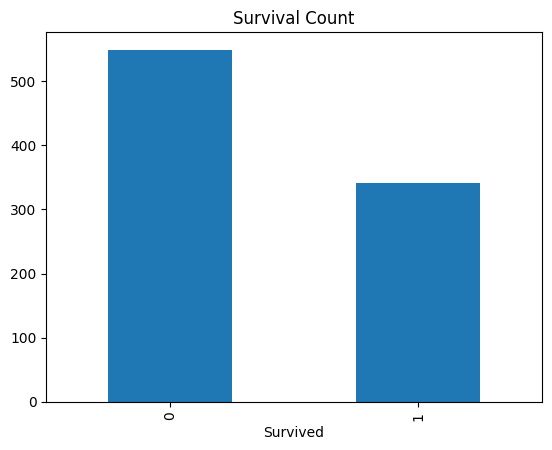

In [41]:
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.show()

# 18. Correlation

In [42]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Fare_log
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658,-0.040143,0.057462,-0.007425
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307,0.016639,-0.203367,0.329862
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500,0.065997,0.135207,-0.661022
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566,-0.248512,0.179775,0.102485
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651,0.890712,-0.584471,0.318528
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225,0.783111,-0.583398,0.332186
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000,0.217138,-0.271832,0.787543
FamilySize,-0.040143,0.016639,0.065997,-0.248512,0.890712,0.783111,0.217138,1.000000,-0.690922,0.383658
IsAlone,0.057462,-0.203367,0.135207,0.179775,-0.584471,-0.583398,-0.271832,-0.690922,1.000000,-0.478410
Fare_log,-0.007425,0.329862,-0.661022,0.102485,0.318528,0.332186,0.787543,0.383658,-0.478410,1.000000


# 19. Export Data

In [50]:
df.to_csv("cleaned_titanic.csv", index=False, encoding="utf-8")

# 20. Key Insights

In [51]:
print("Survival Rate:", df["Survived"].mean())
print("Avg Fare by Class:\n", df.groupby("Pclass")["Fare"].mean())

Survival Rate: 0.3838383838383838
Avg Fare by Class:
 Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


#  🏁 Final Conclusion

* NumPy → fast numerical operations
* pandas → powerful data manipulation
* 📊Together → complete data analysis pipeline


# Why This Notebook is 🔥


* ✔ Covers almost all real-world operations
* ✔ Uses real dataset
* ✔ Shows end-to-end workflow
* ✔ Includes feature engineering (important for ML)
